In [230]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load data

### Import candy sales data

In [231]:
factories_df = pd.read_csv("./data/US Candy Distributors/Candy_Factories.csv")
products_df = pd.read_csv("./data/US Candy Distributors/Candy_Products.csv")
sales_df = pd.read_csv("./data/US Candy Distributors/Candy_Sales.csv", parse_dates=["Ship Date", "Order Date"])
targets_df = pd.read_csv("./data/US Candy Distributors/Candy_Targets.csv")
uszips_df = pd.read_csv("./data/US Candy Distributors/uszips.csv", dtype={"zip": str})

### Columns rename

In [232]:
candy_sales_dfs = {
    "Candy Factories": factories_df,
    "Candy Products": products_df,
    "Candy Sales": sales_df,
    "Candy Tragets": targets_df,
    "US zips": uszips_df
}

# Columns renames
def rename_columns(df):
    return [col.lower().replace(" ", "_").replace("/", "_") for col in df.columns]

for df in candy_sales_dfs.values():
    df.columns = rename_columns(df)

In [233]:
sales_df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'country_region', 'city', 'state_province',
       'postal_code', 'division', 'region', 'product_id', 'product_name',
       'sales', 'units', 'gross_profit', 'cost'],
      dtype='str')

## Plot

### Histogram

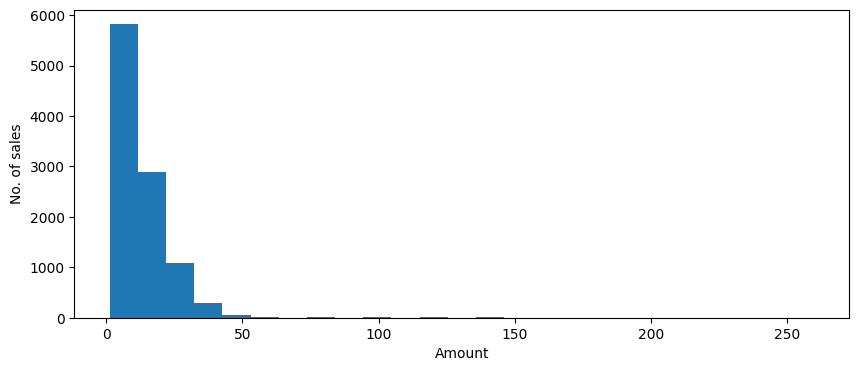

In [234]:
sales_df["sales"].plot(kind="hist", bins=25, figsize=(10, 4), xlabel="Amount", ylabel="No. of sales")
plt.show()

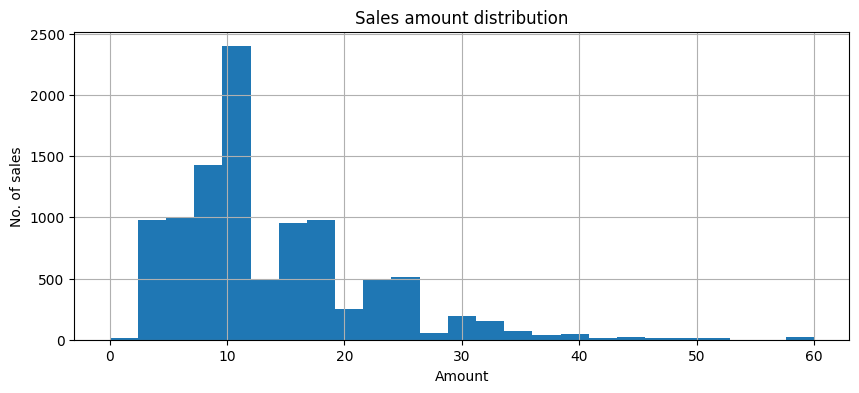

In [235]:
plt.figure(figsize=(10, 4))
plt.hist(sales_df["sales"], bins=25, range=(0, 60))

# Common in all charts
plt.xlabel("Amount")
plt.ylabel("No. of sales")
plt.title("Sales amount distribution")
plt.grid()
plt.show()

### Add month column

In [236]:
sales_df["month"] = sales_df["order_date"].dt.strftime("%Y-%m")
sales_df.head(2)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,country_region,city,state_province,postal_code,division,region,product_id,product_name,sales,units,gross_profit,cost,month
0,282,US-2021-128055-CHO-TRI-54000,2021-03-31,2026-09-26,Standard Class,128055,United States,San Francisco,California,94122,Chocolate,Pacific,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.5,2,4.9,2.6,2021-03
1,288,US-2021-128055-CHO-SCR-58000,2021-03-31,2026-09-26,Standard Class,128055,United States,San Francisco,California,94122,Chocolate,Pacific,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,7.2,2,5.0,2.2,2021-03


### Line chart

In [237]:
monthly_revenue = sales_df.groupby("month")["sales"].sum()
monthly_revenue.values

array([1065.24,  547.09, 2245.63, 2058.97, 1855.21, 1838.43, 1908.23,
       2258.46, 3927.08, 2544.88, 4357.18, 4347.15, 1028.66,  832.78,
       1893.27, 1929.25, 2096.31, 1680.33, 1957.15, 2219.19, 3985.02,
       2271.1 , 4560.53, 4549.06, 1319.68, 1058.31, 2144.68, 2259.44,
       3339.63, 2677.83, 3066.28, 2531.73, 5014.08, 2804.08, 4981.22,
       5662.36, 2169.42, 1495.34, 3278.56, 2663.  , 3216.05, 3537.1 ,
       2991.39, 3208.37, 6443.52, 4541.81, 6747.64, 6675.91])

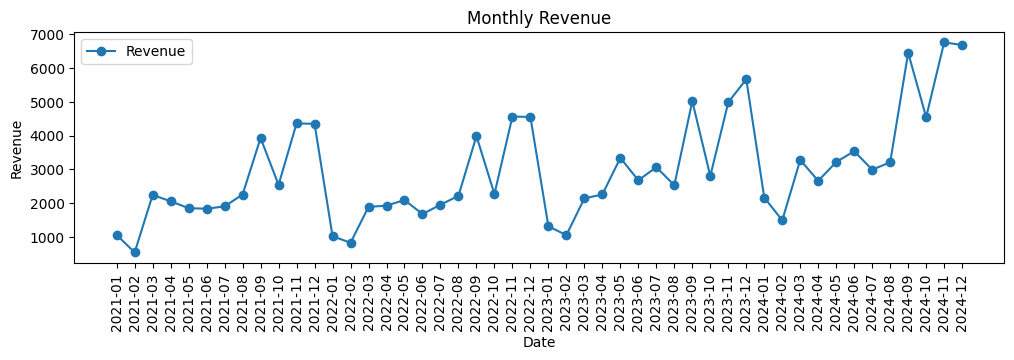

In [252]:
plt.figure(figsize=(12, 3))
plt.plot(monthly_revenue.index, monthly_revenue, label="Revenue", marker="o")
plt.xticks(rotation=90)
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.title("Monthly Revenue")
plt.legend()
plt.show()

In [239]:
monthly_sales_count = sales_df["month"].value_counts().sort_index()
monthly_sales_count.head()

month
2021-01     84
2021-02     46
2021-03    159
2021-04    135
2021-05    132
Name: count, dtype: int64

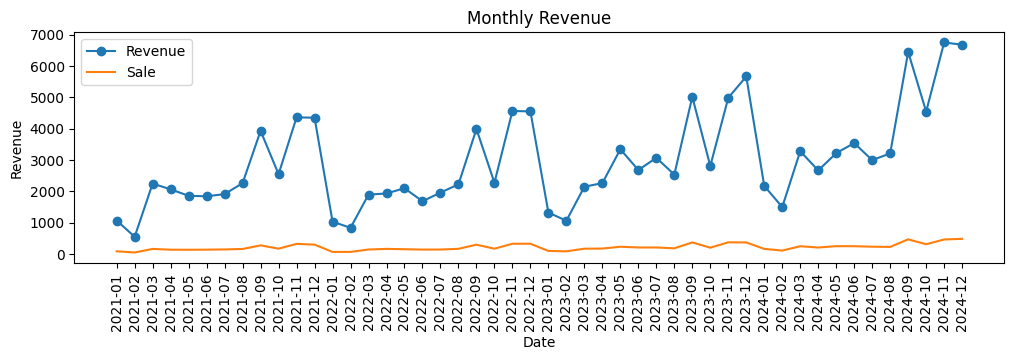

In [240]:
plt.figure(figsize=(12, 3))

plt.plot(monthly_revenue.index, monthly_revenue, label="Revenue", marker='o')
plt.plot(monthly_sales_count.index, monthly_sales_count, label="Sale")

plt.xticks(rotation=90)
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.title("Monthly Revenue")
plt.legend()
plt.show()

### Column chart

In [241]:
product_revenue = sales_df.groupby("product_name")["sales"].sum().sort_values(ascending=False)
product_revenue.head()

product_name
Wonka Bar - Triple Dazzle Caramel    28485.00
Wonka Bar -Scrumdiddlyumptious       27874.80
Wonka Bar - Milk Chocolate           26867.75
Wonka Bar - Fudge Mallows            24890.40
Wonka Bar - Nutty Crunch Surprise    23574.95
Name: sales, dtype: float64

In [242]:
candy_labels = [name.removeprefix("Wonka Bar -").strip() for name in product_revenue.index]
print(candy_labels)

['Triple Dazzle Caramel', 'Scrumdiddlyumptious', 'Milk Chocolate', 'Fudge Mallows', 'Nutty Crunch Surprise', 'Lickable Wallpaper', 'Kazookles', 'Wonka Gum', 'Everlasting Gobstopper', 'Fizzy Lifting Drinks', 'Hair Toffee', 'SweeTARTS', 'Laffy Taffy', 'Nerds', 'Fun Dip']


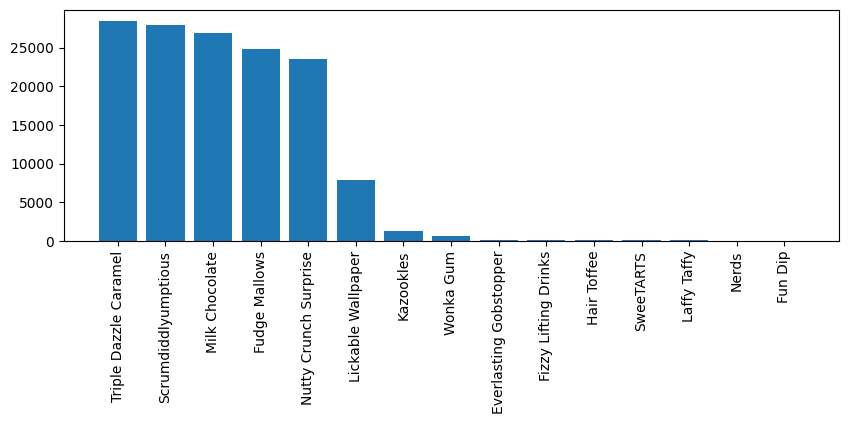

In [253]:
plt.figure(figsize=(10, 3))
plt.bar(product_revenue.index, product_revenue)
plt.xticks(product_revenue.index, candy_labels, rotation=90)
plt.show()

### Horizontal bar char

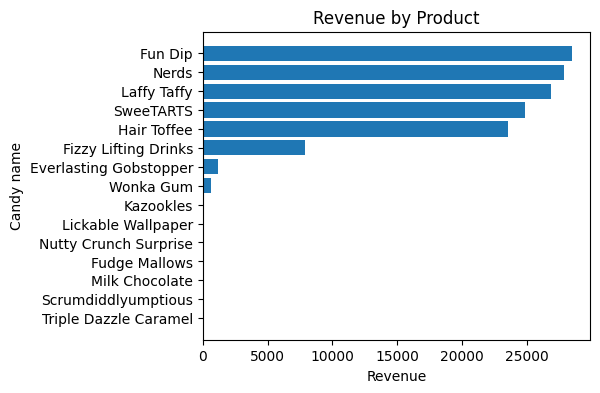

In [244]:
plt.figure(figsize=(5, 4))
plt.barh(product_revenue.index, product_revenue.sort_values(ascending=True))
plt.yticks(product_revenue.index, candy_labels)
plt.ylabel("Candy name")
plt.xlabel("Revenue")
plt.title("Revenue by Product")
plt.show()

### Clustered bar chart

In [245]:
revenue_by_division = sales_df.groupby(["division", "region"])["sales"].sum().unstack()
revenue_by_division


region,Atlantic,Gulf,Interior,Pacific
division,,,,
Chocolate,37580.63,21016.37,30276.11,42819.79
Other,3475.50,1143.50,1686.75,3357.50
Sugar,141.11,87.39,74.74,124.24


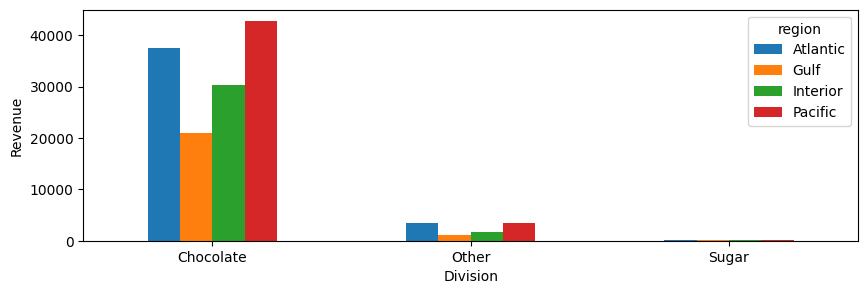

In [246]:
revenue_by_division.plot(kind="bar", figsize=(10, 3))
plt.xticks(rotation=0)
plt.xlabel("Division")
plt.ylabel("Revenue")
plt.show()

### Stacked bar chart

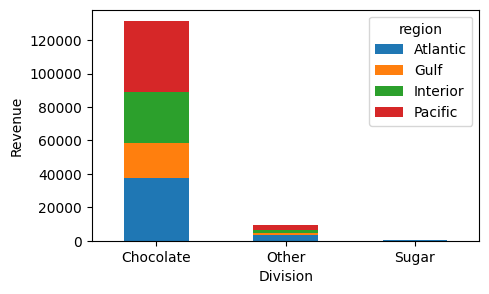

In [247]:
revenue_by_division.plot(kind="bar", figsize=(5, 3), stacked=True)
plt.xticks(rotation=0)
plt.xlabel("Division")
plt.ylabel("Revenue")
plt.show()

### pie chart

In [248]:
revenue_by_region = sales_df.groupby("region")["sales"].sum()
revenue_by_region

region
Atlantic    41197.24
Gulf        22247.26
Interior    32037.60
Pacific     46301.53
Name: sales, dtype: float64

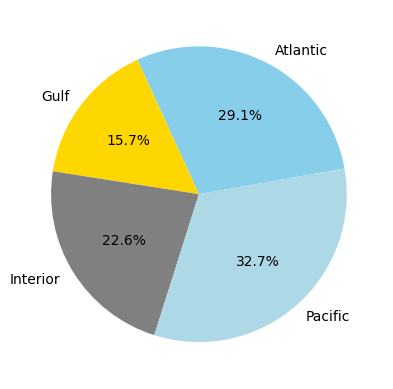

In [249]:
colors = ["skyblue", "gold", "grey", "lightblue"]
plt.pie(revenue_by_region, labels=revenue_by_region.index, startangle=10, autopct="%1.1f%%", colors=colors)
plt.show()

## Sub plots

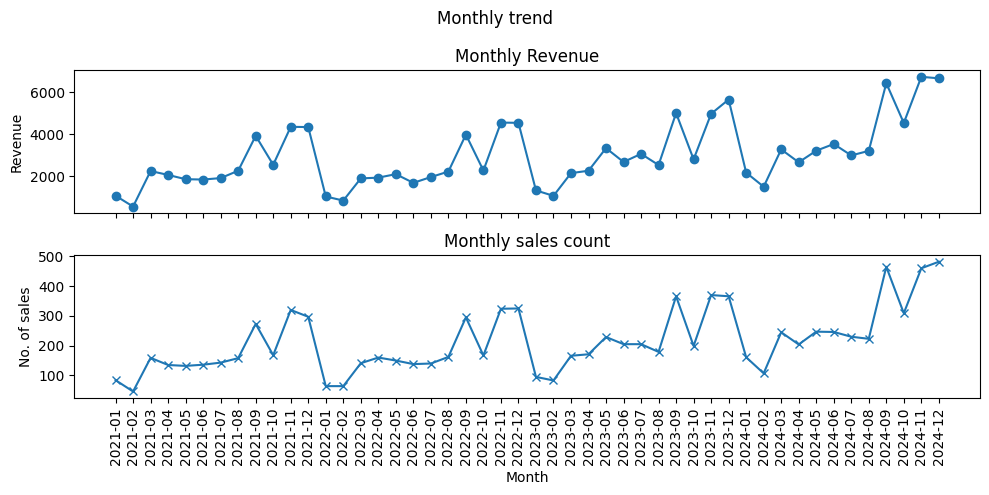

In [250]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

axes[0].plot(monthly_revenue.index, monthly_revenue, label="Revenue", marker="o")
axes[1].plot(monthly_sales_count.index, monthly_sales_count, label="Sale", marker="x")

axes[0].set_ylabel("Revenue")
axes[0].set_title("Monthly Revenue")
axes[1].set_ylabel("No. of sales")
axes[1].set_xlabel("Month")
axes[1].set_title("Monthly sales count")

plt.suptitle("Monthly trend")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

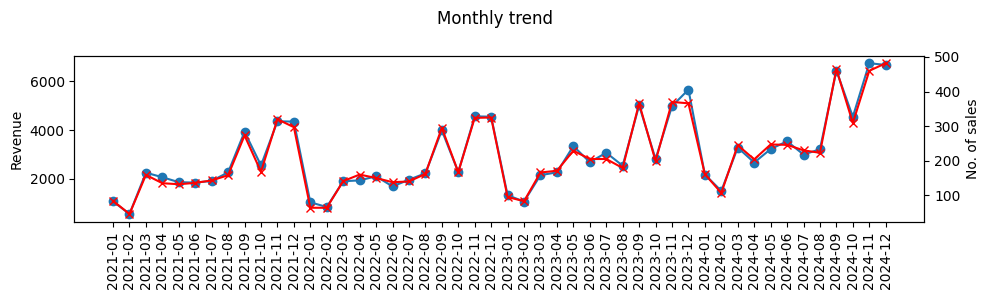

In [251]:
fig, ax1 = plt.subplots(figsize=(10, 3), sharex=True)

ax1.plot(monthly_revenue.index, monthly_revenue, label="Revenue", marker="o")
ax1.set_ylabel("Revenue")

# Plot for monthly_sales_count
ax2 = ax1.twinx()

ax2.plot(monthly_sales_count.index, monthly_sales_count, label="Sale", marker="x", color="Red")
ax2.set_ylabel("No. of sales")
ax2.set_xlabel("Month")

plt.suptitle("Monthly trend")
ax1.tick_params(axis='x', labelrotation=90)
plt.tight_layout()
plt.show()

### 4 x 4 grid

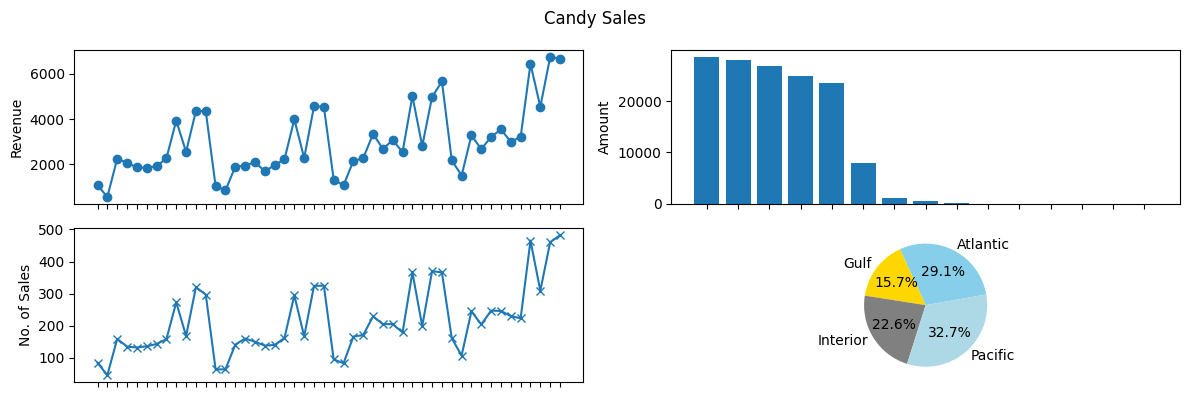

In [272]:
fig, ax = plt.subplots(2, 2, figsize=(12, 4))

ax[0, 0].plot(monthly_revenue.index, monthly_revenue, label="Revenue", marker="o")
ax[0, 1].bar(product_revenue.index, product_revenue)

ax[1, 0].plot(monthly_sales_count.index, monthly_sales_count, label="Sale", marker="x")
ax[1, 1].pie(revenue_by_region, labels=revenue_by_region.index, startangle=10, autopct="%1.1f%%", colors=colors)

ax[0, 0].tick_params(axis='x', labelbottom=False)
ax[0, 1].tick_params(axis='x', labelbottom=False)
ax[1, 0].tick_params(axis='x', labelbottom=False)
ax[1, 1].tick_params(axis='x', labelbottom=False)

ax[0, 0].set_ylabel("Revenue")
ax[0, 1].set_ylabel("Amount")
ax[1, 0].set_ylabel("No. of Sales")

plt.suptitle("Candy Sales")
plt.tight_layout()
plt.show()